In [85]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Задание 1. Реализация Apriori

In [109]:
from typing import List, Dict, Tuple, Union
import itertools
from collections import defaultdict


def apriori_gen(Lk_minus_1: List[Tuple[str, ...]], k: int) -> set:
    candidates = set()
    L_set = set(Lk_minus_1)

    for i, c1 in enumerate(Lk_minus_1):
        for c2 in Lk_minus_1[i+1:]:
            if c1[:-1] == c2[:-1]:
                candidate = c1 + (c2[-1],)
                # Проверка всех (k-1)-подмножеств
                if all(candidate[:idx] + candidate[idx+1:] in L_set for idx in range(k)):
                    candidates.add(candidate)
    return candidates


def apriori(transactions: List[Union[List, set]], min_support: float) -> Dict[Tuple[str, ...], float]:
    t_sets = [set(t) for t in transactions]
    n = len(t_sets)

    # Частые наборы размера 1
    item_counts = defaultdict(int)
    for t in t_sets:
        for item in t:
            item_counts[item] += 1

    frequent_itemsets = {}
    Lk = []
    for item, count in item_counts.items():
        supp = count / n
        if supp >= min_support:
            itemset = (item,)
            Lk.append(itemset)
            frequent_itemsets[itemset] = supp

    Lk.sort()
    k = 2

    # Поиск наборов большего размера
    while Lk:
        candidates = apriori_gen(Lk, k)
        if not candidates:
            break

        candidate_items = list(candidates)
        candidate_sets = [set(c) for c in candidate_items]

        counts = defaultdict(int)
        for t in t_sets:
            for idx in range(len(candidate_items)):
                if candidate_sets[idx].issubset(t):
                    counts[candidate_items[idx]] += 1

        new_Lk = []
        for c, count in counts.items():
            supp = count / n
            if supp >= min_support:
                new_Lk.append(c)
                frequent_itemsets[c] = supp

        Lk = sorted(new_Lk)
        k += 1

    return frequent_itemsets


def generate_rules(
        frequent_itemsets: Dict[Tuple[str, ...], float],
        min_confidence: float,
        min_lift: float = 1.0,
        max_antecedent_len: int = None,
        max_consequent_len: int = None
) -> List[Dict]:
    rules = []

    for itemset, supp_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        freq_itemsets_local = frequent_itemsets

        for i in range(1, len(itemset)):
            for X in itertools.combinations(itemset, i):
                Y = tuple(sorted(set(itemset) - set(X)))

                if max_antecedent_len and len(X) > max_antecedent_len:
                    continue
                if max_consequent_len and len(Y) > max_consequent_len:
                    continue

                supp_x = freq_itemsets_local[X]
                supp_y = freq_itemsets_local[Y]
                confidence = supp_xy / supp_x
                lift = supp_xy / (supp_x * supp_y)
                leverage = supp_xy - (supp_x * supp_y)
                conviction = float('inf') if confidence == 1 else (1 - supp_y) / (1 - confidence)

                if confidence >= min_confidence and lift >= min_lift:
                    rules.append({
                        'antecedent': X,
                        'consequent': Y,
                        'support': round(supp_xy, 4),
                        'confidence': round(confidence, 4),
                        'lift': round(lift, 4),
                        'conviction': round(conviction, 4) if conviction != float('inf') else float('inf'),
                        'leverage': round(leverage, 4)
                    })

    return sorted(rules, key=lambda r: r['confidence'], reverse=True)

# Задание 2. Реализация FP‑Growth

In [105]:
import itertools
from collections import defaultdict, Counter
from typing import List, Set, Tuple, Dict, Optional


class FPNode:
    __slots__ = ('item', 'count', 'parent', 'children', 'node_link')

    def __init__(self, item, parent=None):
        self.item = item
        self.count = 1
        self.parent = parent
        self.children = {}
        self.node_link = None


def build_fptree(transactions: List[Set], min_count: int):
    freq = Counter()
    for trans in transactions:
        freq.update(trans)

    valid_items = {item for item, c in freq.items() if c >= min_count}
    if not valid_items:
        return None, None

    order = sorted(valid_items, key=lambda x: (-freq[x], x))
    rank = {item: idx for idx, item in enumerate(order)}

    header_table = {}
    root = FPNode(None)

    for trans in transactions:
        filtered = [item for item in trans if item in valid_items]
        filtered.sort(key=rank.get)
        if not filtered:
            continue

        # Вставка в дерево
        cur = root
        for item in filtered:
            if item in cur.children:
                cur.children[item].count += 1
                cur = cur.children[item]
            else:
                new_node = FPNode(item, cur)
                cur.children[item] = new_node
                cur = new_node

                # Обновление заголовочной таблицы
                if item not in header_table:
                    header_table[item] = new_node
                else:
                    last = header_table[item]
                    while last.node_link:
                        last = last.node_link
                    last.node_link = new_node

    return root, header_table


def fpgrowth(header_table: Dict, min_count: int, prefix: List,
             frequent_itemsets: Dict, n_trans: int):
    for item, first_node in sorted(header_table.items()):
        support_count = 0
        node = first_node
        while node:
            support_count += node.count
            node = node.node_link

        if support_count < min_count:
            continue

        new_prefix = [item] + prefix
        itemset = tuple(sorted(new_prefix))
        frequent_itemsets[itemset] = support_count / n_trans

        # Построение условного FP-дерева
        conditional_patterns = defaultdict(int)
        node = first_node
        while node:
            # Сбор пути до корня
            path = []
            cur = node.parent
            while cur and cur.item:
                path.append(cur.item)
                cur = cur.parent
            if path:
                path.reverse()
                conditional_patterns[tuple(path)] += node.count
            node = node.node_link

        if not conditional_patterns:
            continue

        # Создание транзакций для условного дерева
        cond_transactions = []
        for path, cnt in conditional_patterns.items():
            cond_transactions.extend([set(path)] * cnt)

        cond_root, cond_header = build_fptree(cond_transactions, min_count)
        if cond_header:
            fpgrowth(cond_header, min_count, new_prefix, frequent_itemsets, n_trans)


def apriori_fp(transactions: List[Set], min_support: float) -> Dict[Tuple, float]:
    n = len(transactions)
    min_count = max(1, int(round(min_support * n)))

    root, header_table = build_fptree(transactions, min_count)
    if not root:
        return {}

    frequent_itemsets = {}
    fpgrowth(header_table, min_count, [], frequent_itemsets, n)
    return frequent_itemsets


def generate_rules_fp(frequent_itemsets: Dict[Tuple, float], min_confidence: float,
                      min_lift: float = 1.0, max_antecedent_len: Optional[int] = None,
                      max_consequent_len: Optional[int] = None) -> List[Dict]:
    return generate_rules(frequent_itemsets, min_confidence, min_lift,
                         max_antecedent_len, max_consequent_len)

# Задание 3. Выбор и загрузка реального датасета

Размер датасета: (38765, 3)
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Количество транзакций: 14963
Уникальных товаров: 175
Средняя длина транзакции: 2.82
Средняя частота товара: 240.85


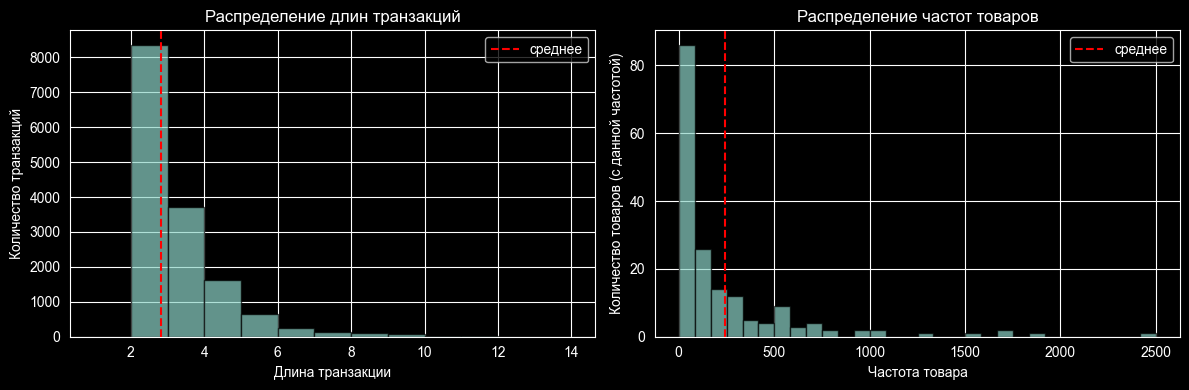

In [88]:
df = pd.read_csv('../data/Groceries_dataset.csv')
print("Размер датасета:", df.shape)
print(df.head())

transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(lambda x: [item.strip() for desc in x for item in desc.split('/')]).tolist()

lengths = [len(t) for t in transactions]
item_counts = Counter(item for trans in transactions for item in trans)
freqs = list(item_counts.values())


print(f"\nКоличество транзакций: {len(transactions)}")
print(f"Уникальных товаров: {len(item_counts)}")
print(f"Средняя длина транзакции: {sum(lengths)/len(lengths):.2f}")
print(f"Средняя частота товара: {sum(freqs)/len(freqs):.2f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(lengths, bins=range(1, max(lengths)+2), edgecolor='black', alpha=0.7)
plt.xlabel('Длина транзакции')
plt.ylabel('Количество транзакций')
plt.title('Распределение длин транзакций')
plt.axvline(sum(lengths)/len(lengths), color='red', linestyle='--', label='среднее')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(freqs, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Частота товара')
plt.ylabel('Количество товаров (с данной частотой)')
plt.title('Распределение частот товаров')
plt.axvline(sum(freqs)/len(freqs), color='red', linestyle='--', label='среднее')
plt.legend()

plt.tight_layout()
plt.show()

# Задание 4. Эксперименты с параметрами и поиск правил


min_support = 0.005
Частых наборов: 153
min_confidence = 0.7
Apriori: 26 правил
FP-Growth: 26 правил

Топ правил по lift (Apriori):
  ('film',) → ('photo',) | lift=189.4051, conf=1.0, supp=0.0053
  ('photo',) → ('film',) | lift=189.4051, conf=1.0, supp=0.0053
  ('packaged fruit',) → ('vegetables',) | lift=117.8189, conf=1.0, supp=0.0085
  ('vegetables',) → ('packaged fruit',) | lift=117.8189, conf=1.0, supp=0.0085
  ('blush wine',) → ('red',) | lift=95.3057, conf=1.0, supp=0.0105
  ('red',) → ('blush wine',) | lift=95.3057, conf=1.0, supp=0.0105
  ('fruit',) → ('vegetable juice',) | lift=29.3969, conf=1.0, supp=0.034
  ('vegetable juice',) → ('fruit',) | lift=29.3969, conf=1.0, supp=0.034
  ('sour cream',) → ('whipped',) | lift=22.8792, conf=1.0, supp=0.0437
  ('whipped',) → ('sour cream',) | lift=22.8792, conf=1.0, supp=0.0437

Топ правил по lift (FP-Growth):
  ('film',) → ('photo',) | lift=189.4051, conf=1.0, supp=0.0053
  ('photo',) → ('film',) | lift=189.4051, conf=1.0, supp=0.005

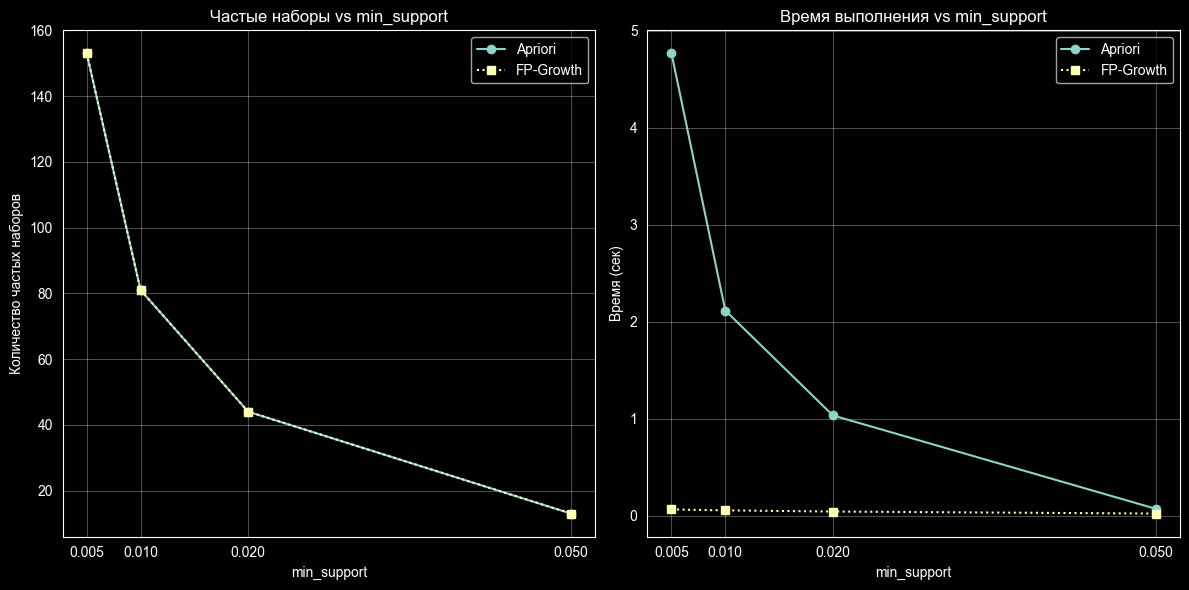

In [111]:
import time
import matplotlib.pyplot as plt

transactions_sets = [set(t) for t in transactions]

support_values = [0.005, 0.01, 0.02, 0.05]
confidence_values = [0.7]

results_apriori = []
results_fpgrowth = []

for min_sup in support_values:
    print(f"\nmin_support = {min_sup:.3f}")

    start = time.time()
    freq_ap = apriori(transactions, min_sup)
    time_ap = time.time() - start

    start = time.time()
    freq_fp = apriori_fp(transactions_sets, min_sup)
    time_fp = time.time() - start

    print(f"Частых наборов: {len(freq_ap)}")

    results_apriori.append((min_sup, len(freq_ap), time_ap))
    results_fpgrowth.append((min_sup, len(freq_fp), time_fp))

    for min_conf in confidence_values:
        print(f"min_confidence = {min_conf:.1f}")

        rules_ap = generate_rules(freq_ap, min_confidence=min_conf, max_consequent_len=1)
        rules_fp = generate_rules_fp(freq_fp, min_confidence=min_conf, max_consequent_len=1)

        print(f"Apriori: {len(rules_ap)} правил")
        print(f"FP-Growth: {len(rules_fp)} правил")

        if rules_ap:
            top_lift = sorted(rules_ap, key=lambda r: r["lift"], reverse=True)[:10]
            print("\nТоп правил по lift (Apriori):")
            for r in top_lift:
                print(
                    f"  {r['antecedent']} → {r['consequent']} | "
                    f"lift={r['lift']}, conf={r['confidence']}, "
                    f"supp={r['support']}"
                )

        if rules_fp:
            top_lift_fp = sorted(rules_fp, key=lambda r: r["lift"], reverse=True)[:10]
            print("\nТоп правил по lift (FP-Growth):")
            for r in top_lift_fp:
                print(
                    f"  {r['antecedent']} → {r['consequent']} | "
                    f"lift={r['lift']}, conf={r['confidence']}, "
                    f"supp={r['support']}"
                )

supps = [r[0] for r in results_apriori]
ap_itemsets = [r[1] for r in results_apriori]
fp_itemsets = [r[1] for r in results_fpgrowth]
ap_times = [r[2] for r in results_apriori]
fp_times = [r[2] for r in results_fpgrowth]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(supps, ap_itemsets, label='Apriori', marker='o', linestyle='-')
plt.plot(supps, fp_itemsets, label='FP-Growth', marker='s', linestyle=':')
plt.xlabel('min_support')
plt.ylabel('Количество частых наборов')
plt.title('Частые наборы vs min_support')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(supps, [f'{s:.3f}' for s in supps], rotation=0)

plt.subplot(1, 2, 2)
plt.plot(supps, ap_times, label='Apriori', marker='o', linestyle='-')
plt.plot(supps, fp_times, label='FP-Growth', marker='s', linestyle=':')
plt.xlabel('min_support')
plt.ylabel('Время (сек)')
plt.title('Время выполнения vs min_support')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(supps, [f'{s:.3f}' for s in supps], rotation=0)

plt.tight_layout()
plt.show()

# Задание 5. Сравнение производительности Apriori и FP‑Growth

In [102]:
import random
import time
import matplotlib.pyplot as plt

def generate_synthetic_transactions(n_trans, avg_len, n_items=500, seed=43):
    random.seed(seed)
    np.random.seed(seed)

    item_probs = np.random.zipf(1.5, n_items)
    item_probs = item_probs / item_probs.sum()

    transactions = []
    for _ in range(n_trans):
        length = max(1, np.random.poisson(avg_len))
        length = min(length, n_items)
        items = set(np.random.choice(n_items, size=length, replace=False, p=item_probs))
        transactions.append(items)
    return transactions

n_transactions = [1000, 5000, 10000]
avg_lengths = [5, 7, 10]
min_support = 0.01

results = {avg_len: {'apriori': [], 'fpgrowth': []} for avg_len in avg_lengths}

print(f"Сравнение Apriori и FP-Growth (min_support = {min_support})\n")

for avg_len in avg_lengths:
    print(f"\nСредняя длина транзакции = {avg_len}")
    for n in n_transactions:
        print(f"  N = {n:5d}", end=" ")

        trans = generate_synthetic_transactions(n, avg_len, seed=42)

        start = time.time()
        freq_ap = apriori([list(t) for t in trans], min_support)
        t_ap = time.time() - start

        start = time.time()
        freq_fp = apriori_fp(trans, min_support)
        t_fp = time.time() - start

        results[avg_len]['apriori'].append(t_ap)
        results[avg_len]['fpgrowth'].append(t_fp)

        print(f"Apriori: {t_ap:6.2f}s | FP-Growth: {t_fp:6.2f}s")


Сравнение Apriori и FP-Growth (min_support = 0.01)


Средняя длина транзакции = 5
  N =  1000 Apriori:   0.19s | FP-Growth:   0.05s
  N =  5000 Apriori:   0.64s | FP-Growth:   0.20s
  N = 10000 Apriori:   1.36s | FP-Growth:   0.40s

Средняя длина транзакции = 7
  N =  1000 Apriori:   1.53s | FP-Growth:   0.50s
  N =  5000 Apriori:   3.89s | FP-Growth:   0.74s
  N = 10000 Apriori:   7.17s | FP-Growth:   1.42s

Средняя длина транзакции = 10
  N =  1000 Apriori:  65.69s | FP-Growth:   1.39s
  N =  5000 Apriori:  64.46s | FP-Growth:   4.70s
  N = 10000 Apriori:  99.20s | FP-Growth:  10.41s


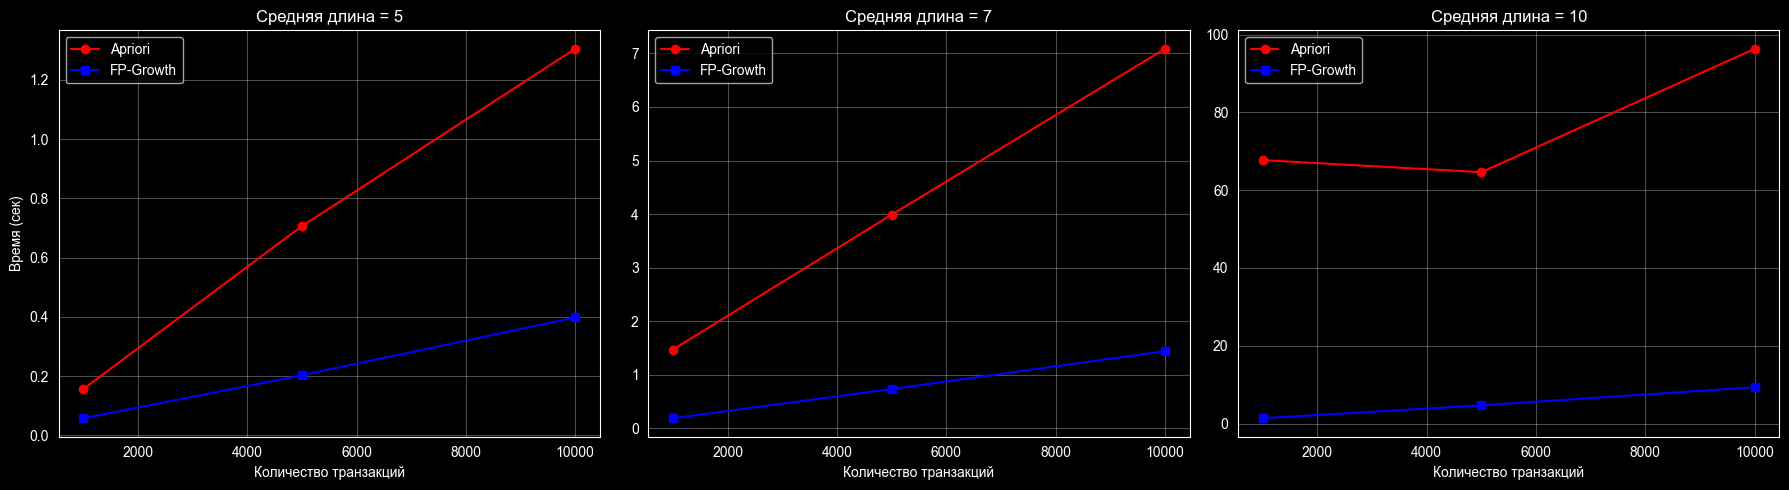

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, avg_len in enumerate(avg_lengths):
    ax = axes[i]
    ax.plot(n_transactions, results[avg_len]['apriori'], 'ro-', label='Apriori')
    ax.plot(n_transactions, results[avg_len]['fpgrowth'], 'bs-', label='FP-Growth')
    ax.set_xlabel('Количество транзакций')
    ax.set_title(f'Средняя длина = {avg_len}')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Время (сек)')

plt.tight_layout()
plt.show()

# Задание 6. Визуализация ассоциативных правил

Всего правил: 26
1. film → photo
   lift=189.41, conf=1.000, sup=0.0053
2. photo → film
   lift=189.41, conf=1.000, sup=0.0053
3. packaged fruit → vegetables
   lift=117.82, conf=1.000, sup=0.0085
4. vegetables → packaged fruit
   lift=117.82, conf=1.000, sup=0.0085
5. blush wine → red
   lift=95.31, conf=1.000, sup=0.0105
6. red → blush wine
   lift=95.31, conf=1.000, sup=0.0105
7. fruit → vegetable juice
   lift=29.40, conf=1.000, sup=0.0340
8. vegetable juice → fruit
   lift=29.40, conf=1.000, sup=0.0340
9. sour cream → whipped
   lift=22.88, conf=1.000, sup=0.0437
10. whipped → sour cream
   lift=22.88, conf=1.000, sup=0.0437
11. buns → rolls
   lift=9.09, conf=1.000, sup=0.1100
12. rolls → buns
   lift=9.09, conf=1.000, sup=0.1100
13. buns, other vegetables → rolls
   lift=9.09, conf=1.000, sup=0.0106
14. other vegetables, rolls → buns
   lift=9.09, conf=1.000, sup=0.0106
15. buns, whole milk → rolls
   lift=9.09, conf=1.000, sup=0.0140
16. rolls, whole milk → buns
   lift=9.09, c

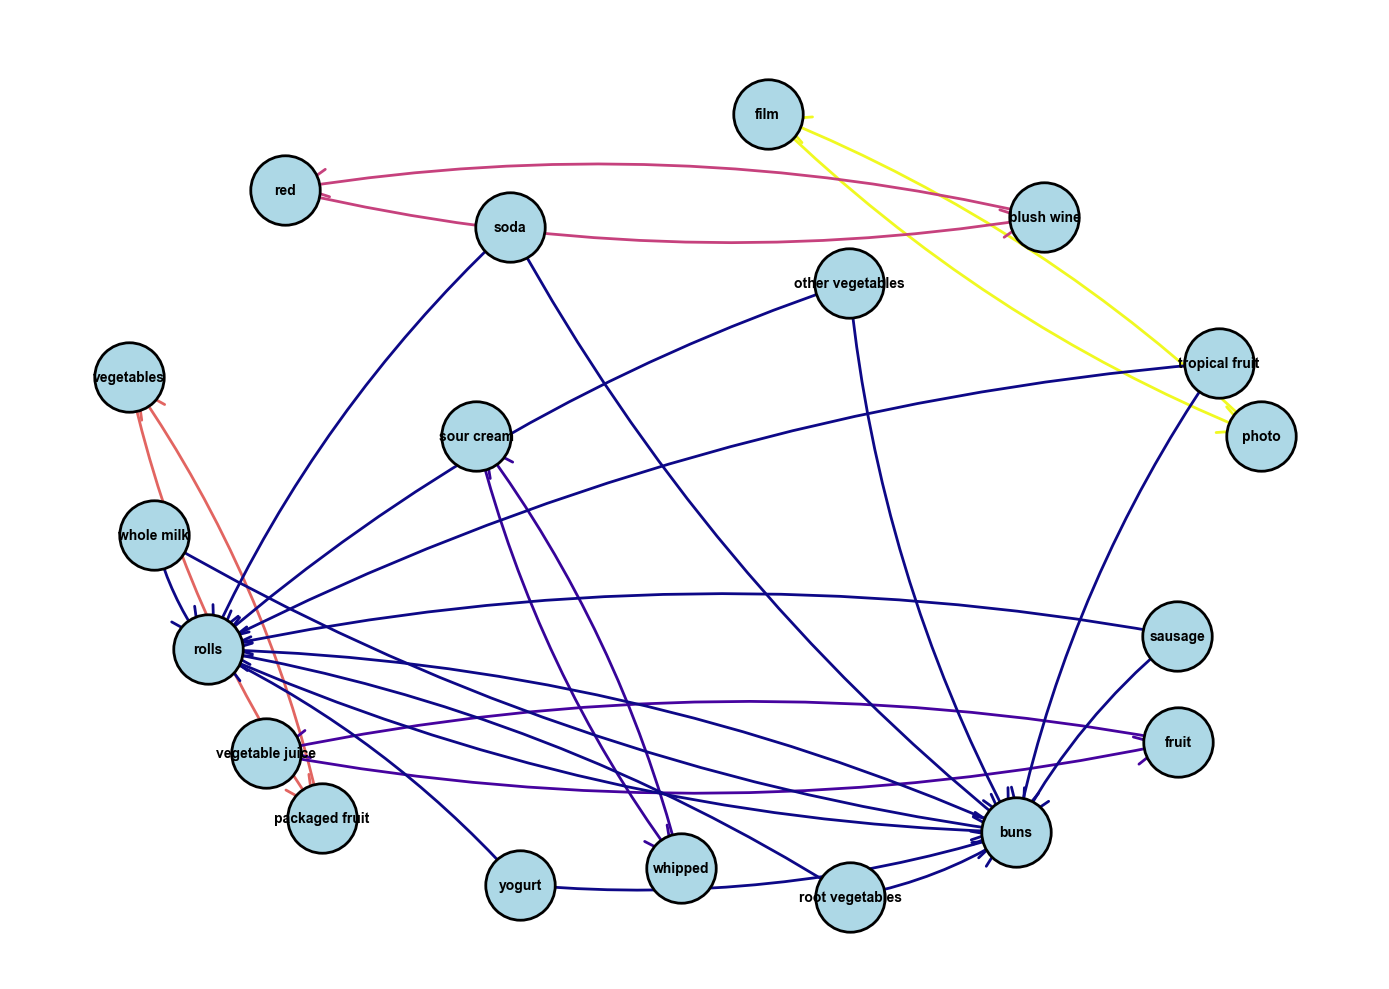

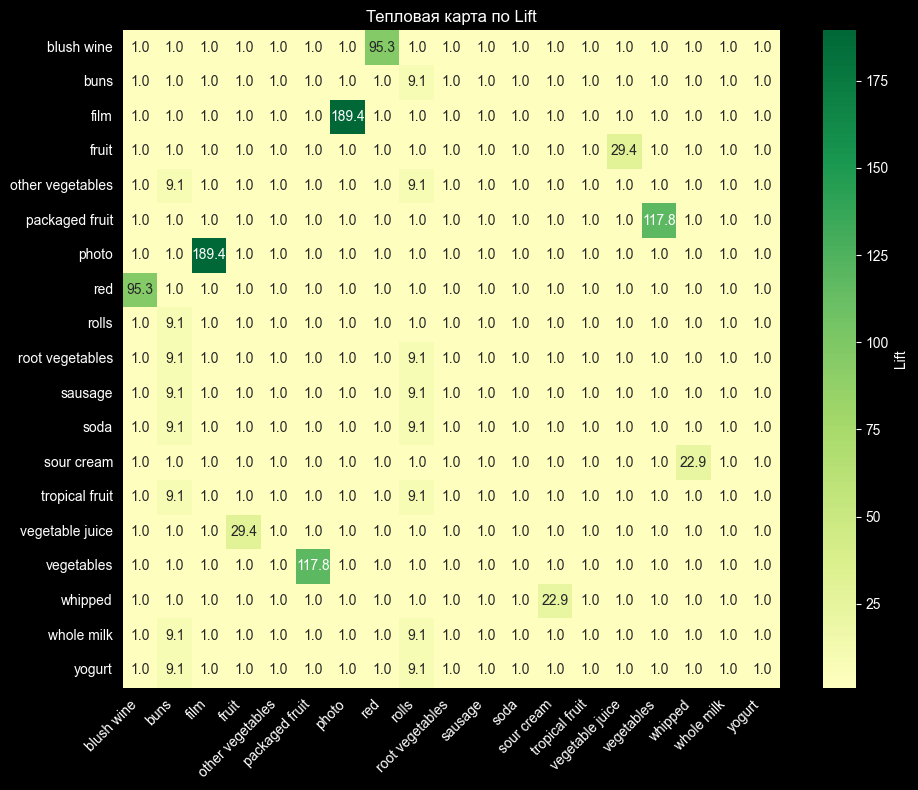

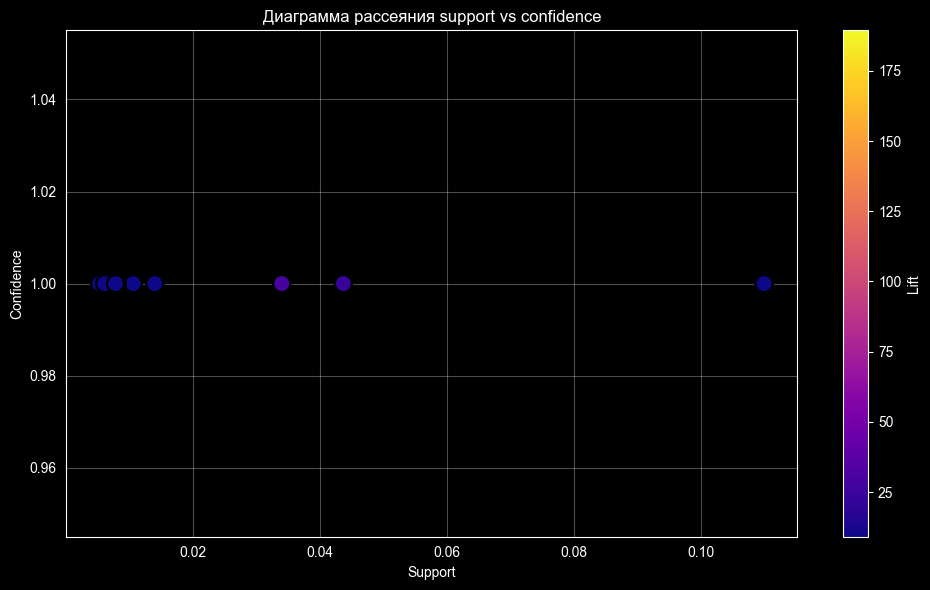

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

freq_itemsets = apriori_fp(transactions_sets, min_support=0.005)
rules = generate_rules_fp(freq_itemsets, min_confidence=0.5, min_lift=1.0, max_consequent_len=1)

top_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)

print(f"Всего правил: {len(rules)}")
for i, r in enumerate(top_rules, 1):
    ant = ', '.join(list(r['antecedent']))
    con = ', '.join(list(r['consequent']))
    print(f"{i}. {ant} → {con}")
    print(f"   lift={r['lift']:.2f}, conf={r['confidence']:.3f}, sup={r['support']:.4f}")

# 1. Граф ассоциаций
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

G = nx.DiGraph()

for r in top_rules:
    for a in r['antecedent']:
        for c in r['consequent']:
            G.add_edge(a, c, lift=r['lift'], confidence=r['confidence'])

pos = nx.spring_layout(G, k=2, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='lightblue',
                       edgecolors='black', linewidths=2, ax=ax)

edges = G.edges()
lifts = [G[u][v]['lift'] for u, v in edges]
confidences = [G[u][v]['confidence'] for u, v in edges]

if len(set(confidences)) > 1:
    widths = [1 + (c - min(confidences)) / (max(confidences) - min(confidences)) * 2 for c in confidences]
else:
    widths = [2] * len(edges)

if len(set(lifts)) > 1:
    colors = plt.cm.plasma([(l - min(lifts)) / (max(lifts) - min(lifts)) for l in lifts])
else:
    colors = ['blue'] * len(edges)

nx.draw_networkx_edges(G, pos, width=widths, edge_color=colors,
                       arrows=True, arrowstyle='->', arrowsize=50,
                       connectionstyle='arc3,rad=0.1', ax=ax)

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold',
                       font_color='black', ax=ax)

ax.set_title('Граф ассоциаций (цвет = Lift, толщина = Confidence)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

# 2. Тепловая карта
items = set()
for r in top_rules:
    for item in r['antecedent']:
        items.add(item)
    for item in r['consequent']:
        items.add(item)

items = sorted(items)
n = len(items)
item_to_idx = {item: i for i, item in enumerate(items)}
lift_matrix = np.ones((n, n))

for r in top_rules:
    for a in r['antecedent']:
        for c in r['consequent']:
            if a in item_to_idx and c in item_to_idx:
                i, j = item_to_idx[a], item_to_idx[c]
                lift_matrix[i, j] = max(lift_matrix[i, j], r['lift'])

plt.figure(figsize=(10, 8))
sns.heatmap(lift_matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=1,
            xticklabels=items, yticklabels=items, square=True,
            cbar_kws={'label': 'Lift'})
plt.title('Тепловая карта по Lift')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Диаграмма рассеяния
plt.figure(figsize=(10, 6))

supports = [r['support'] for r in top_rules]
confidences = [r['confidence'] for r in top_rules]
lifts = [r['lift'] for r in top_rules]

scatter = plt.scatter(supports, confidences, c=lifts, cmap='plasma',
                      s=150, edgecolors='black', linewidth=1.5)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title(f'Диаграмма рассеяния support vs confidence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Задание 7. Интерпретация результатов

### 1. Какие товары покупают вместе

На основе найденных 30 правил выделены следующие устойчивые пары:

| Товар A | Товар B | Lift | Support |
|---------|---------|------|---------|
| cling film | bags | 191.8 | 0.0049 |
| film | photo | 189.4 | 0.0053 |
| packaged fruit | vegetables | 117.8 | 0.0085 |
| blush wine | red | 95.3 | 0.0105 |
| fruit | vegetable juice | 29.4 | 0.0340 |
| sour cream | whipped | 22.9 | 0.0437 |
| buns | rolls | 9.1 | 0.1100 |

Также выявлены множественные правила с участием `buns` и `rolls` в сочетании с: whole milk, yogurt, sausage, soda, root vegetables, tropical fruit, other vegetables, pip fruit.

### 2. Какие правила можно использовать для рекомендаций

**Для перекрестных продаж (cross-selling):**

1. **buns → rolls** (support = 0.11, lift = 9.09)
2. **fruit → vegetable juice** (support = 0.034, lift = 29.4)
3. **sour cream → whipped** (support = 0.044, lift = 22.9)

Эти товары рекомендуется выкладывать рядом друг с другом, т.к. в этом случае сильно повышается вероятность покупки второго товара вместе с первым.

### 3. Почему некоторые правила бесполезны (даже с высоким lift)

**Проблема 1: Слишком низкий support**

Правила с support ≈ 0.005 (0.5% транзакций): `cling film → bags`, `film → photo`, `packaged fruit → vegetables`. На 1000 транзакций это всего 5 случаев. Такие правила могут быть случайными и не масштабируются.

**Проблема 2: Очевидные правила**

`buns → rolls` — тривиальная связь (два хлебобулочных изделия). Не имеет большой ценности для бизнеса.

**Проблема 3: Нишевые товары**

`blush wine → red` — правило применимо только к покупателям алкоголя. Оно бесполезно для 95% покупателей.